# HW08-09

In [1]:
# Imports, seed, device
import os
import json
import random
import numpy as np
import math
import matplotlib.pyplot as plt
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Subset
import torchvision
from torchvision import transforms
from tqdm.auto import tqdm

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
ROOT = Path('.').resolve()
ARTIFACTS = ROOT / 'homeworks' / 'HW08-09' / 'artifacts'
ARTIFACTS.mkdir(parents=True, exist_ok=True)
(ARTIFACTS / 'figures').mkdir(parents=True, exist_ok=True)

Device: cpu


In [2]:
dataset_name = 'EMNIST'
DatasetCls = lambda root, train, transform, download: torchvision.datasets.EMNIST(root=root, split='balanced', train=train, transform=transform, download=download)
n_channels = 1
img_size = (28,28)
n_classes = 47

transform = transforms.Compose([
    transforms.ToTensor()
    # Normalize can be added if desired
])

data_root = './data'
train_full = DatasetCls(root=data_root, train=True, transform=transform, download=True)
test_set = DatasetCls(root=data_root, train=False, transform=transform, download=True)

val_ratio = 0.2
n_train = len(train_full)
n_val = int(val_ratio * n_train)
n_train_new = n_train - n_val
train_set, val_set = random_split(train_full, [n_train_new, n_val], generator=torch.Generator().manual_seed(SEED))
train_set = Subset(train_set, range(20000))
val_set = Subset(val_set, range(5000))

batch_size = 256
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=0)

x_example, y_example = next(iter(train_loader))
print('Batch shapes:', x_example.shape, y_example.shape) 
print('Value range:', x_example.min().item(), x_example.max().item())

Batch shapes: torch.Size([256, 1, 28, 28]) torch.Size([256])
Value range: 0.0 1.0


In [3]:
class MLP(nn.Module):
    def __init__(self, in_features, hidden_sizes=[512,256], n_classes=10, dropout_p=0.0, use_batchnorm=False, activation=nn.ReLU):
        super().__init__()
        layers = []
        last = in_features
        for i, h in enumerate(hidden_sizes):
            layers.append(nn.Linear(last, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(activation())
            if dropout_p and dropout_p>0:
                layers.append(nn.Dropout(p=dropout_p))
            last = h
        layers.append(nn.Linear(last, 47))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

in_features = n_channels * img_size[0] * img_size[1]
print('Input features:', in_features)


Input features: 784


In [4]:
def accuracy(outputs, targets):
    preds = outputs.argmax(dim=1)
    return (preds == targets).float().mean().item()

def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    n = 0
    for x, y in tqdm(loader, desc="Training", leave=False):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()
        b = x.size(0)
        running_loss += loss.item() * b
        running_acc += accuracy(logits, y) * b
        n += b
    return running_loss / n, running_acc / n

@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    running_loss = 0.0
    running_acc = 0.0
    n = 0
    for x,y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = loss_fn(logits, y)
        b = x.size(0)
        running_loss += loss.item() * b
        running_acc += accuracy(logits, y) * b
        n += b
    return running_loss / n, running_acc / n


In [5]:
import time
def run_experiment(experiment_id, hidden_sizes=[512,256], dropout_p=0.0, use_batchnorm=False,
                   optimizer_name='Adam', lr=1e-3, momentum=0.0, weight_decay=0.0,
                   max_epochs=15, early_stopping=None, save_model=False):
    model = MLP(in_features=in_features, hidden_sizes=hidden_sizes, n_classes=10, dropout_p=dropout_p, use_batchnorm=use_batchnorm).to(DEVICE)
    loss_fn = nn.CrossEntropyLoss()
    if optimizer_name.lower() == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name.lower() == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    else:
        raise ValueError(optimizer_name)
    history = {'epoch':[], 'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
    best_val_acc = 0.0
    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0
    t0 = time.time()
    for epoch in tqdm(range(1, max_epochs+1), desc=f"Experiment {experiment_id}"):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, DEVICE)
        val_loss, val_acc = evaluate(model, val_loader, loss_fn, DEVICE)
        history['epoch'].append(epoch)
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        if val_acc > best_val_acc or (val_acc == best_val_acc and val_loss < best_val_loss):
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_state = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        
        if early_stopping is not None and epochs_no_improve >= early_stopping:
            print(f'[{experiment_id}] Early stopping at epoch {epoch}')
            break
    print(f"Epoch {epoch}: train_loss={tr_loss:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}")
    elapsed = time.time() - t0
    
    if save_model and best_state is not None:
        fname = ARTIFACTS / f'best_model_{experiment_id}.pt'
        torch.save(best_state, fname)
    
    return {
        'experiment_id': experiment_id,
        'dataset': dataset_name,
        'seed': SEED,
        'model_summary': f'hidden={hidden_sizes}, dropout={dropout_p}, batchnorm={use_batchnorm}',
        'optimizer': optimizer_name,
        'lr': lr,
        'momentum': momentum,
        'weight_decay': weight_decay,
        'epochs_trained': len(history['epoch']),
        'best_val_accuracy': best_val_acc,
        'best_val_loss': best_val_loss,
        'history': history
    }

## Эксперименты (конфигурации)
В этом блоке заданы конфиги E1–E4 (регуляризация) и O1–O3 (оптимизация). Запустите нужные прогоны вручную или выполните их все.

In [6]:
experiments = {
    'E1': dict(hidden_sizes=[256,128], dropout_p=0.0, use_batchnorm=False, optimizer_name='Adam', lr=1e-3, max_epochs=6),
    'E2': dict(hidden_sizes=[256,128], dropout_p=0.3, use_batchnorm=False, optimizer_name='Adam', lr=1e-3, max_epochs=6),
    'E3': dict(hidden_sizes=[256,128], dropout_p=0.0, use_batchnorm=True, optimizer_name='Adam', lr=1e-3, max_epochs=6),

    # experiments with learning rate
    'O1': dict(hidden_sizes=[256,128], dropout_p=0.3, use_batchnorm=True, optimizer_name='Adam', lr=1e-1, max_epochs=5),
    'O2': dict(hidden_sizes=[256,128], dropout_p=0.3, use_batchnorm=True, optimizer_name='Adam', lr=1e-5, max_epochs=5),
    'O3': dict(hidden_sizes=[256,128], dropout_p=0.3, use_batchnorm=True, optimizer_name='SGD', lr=1e-3, momentum=0.9, weight_decay=1e-4, max_epochs=6),
}

for k, v in experiments.items():
    print(k, v)


E1 {'hidden_sizes': [256, 128], 'dropout_p': 0.0, 'use_batchnorm': False, 'optimizer_name': 'Adam', 'lr': 0.001, 'max_epochs': 6}
E2 {'hidden_sizes': [256, 128], 'dropout_p': 0.3, 'use_batchnorm': False, 'optimizer_name': 'Adam', 'lr': 0.001, 'max_epochs': 6}
E3 {'hidden_sizes': [256, 128], 'dropout_p': 0.0, 'use_batchnorm': True, 'optimizer_name': 'Adam', 'lr': 0.001, 'max_epochs': 6}
O1 {'hidden_sizes': [256, 128], 'dropout_p': 0.3, 'use_batchnorm': True, 'optimizer_name': 'Adam', 'lr': 0.1, 'max_epochs': 5}
O2 {'hidden_sizes': [256, 128], 'dropout_p': 0.3, 'use_batchnorm': True, 'optimizer_name': 'Adam', 'lr': 1e-05, 'max_epochs': 5}
O3 {'hidden_sizes': [256, 128], 'dropout_p': 0.3, 'use_batchnorm': True, 'optimizer_name': 'SGD', 'lr': 0.001, 'momentum': 0.9, 'weight_decay': 0.0001, 'max_epochs': 6}



Running E1


Experiment E1:   0%|          | 0/6 [00:00<?, ?it/s]

Training:   0%|          | 0/79 [00:00<?, ?it/s]

Training:   0%|          | 0/79 [00:00<?, ?it/s]

Training:   0%|          | 0/79 [00:00<?, ?it/s]

...

Training:   0%|          | 0/79 [00:00<?, ?it/s]

Training:   0%|          | 0/79 [00:00<?, ?it/s]

Training:   0%|          | 0/79 [00:00<?, ?it/s]

Training:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 6: train_loss=2.5392 val_loss=2.3793 val_acc=0.5202


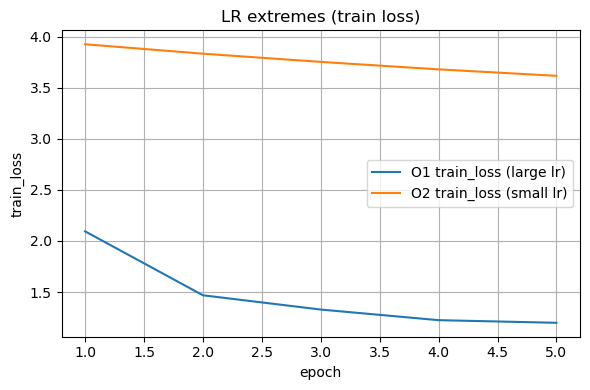

In [10]:
import csv
runs_csv = ARTIFACTS / 'runs.csv'
header = ['experiment_id','dataset','seed','model_summary','optimizer','lr','momentum','weight_decay','epochs_trained','best_val_accuracy','best_val_loss']
if not runs_csv.exists():
    with open(runs_csv,'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(header)

results = {}
for exp_id in ['E1','E2','E3']:
    cfg = experiments[exp_id]
    print('\nRunning', exp_id)
    summary = run_experiment(exp_id, **cfg)
    results[exp_id] = summary
    # append to csv
    with open(runs_csv,'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([summary[h] for h in header])


best_of = max(('E2','E3'), key=lambda k: results[k]['best_val_accuracy'])
print('Best of E2/E3:', best_of)

best_cfg = experiments[best_of].copy()
summary_e4 = run_experiment('E4', early_stopping=4, save_model=True, **best_cfg)
with open(runs_csv,'a', newline='') as f:
    writer = csv.writer(f)
    writer.writerow([summary_e4[h] for h in header])
results['E4'] = summary_e4

for exp_id in ['O1','O2','O3']:
    cfg = experiments[exp_id]
    print('\nRunning', exp_id)
    summary = run_experiment(exp_id, **cfg)
    results[exp_id] = summary
    with open(runs_csv,'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([summary[h] for h in header])

best_model_path = ARTIFACTS / 'best_model.pt'
if 'E4' in results and results['E4'].get('history'):
    src = ARTIFACTS / 'best_model_E4.pt'
    if src.exists():
        import shutil
        shutil.copy(src, best_model_path)

    best_cfg = experiments[best_of].copy()
    best_config = {
        'experiment_id': 'E4',
        'dataset': dataset_name,
        'seed': SEED,
        'hidden_sizes': best_cfg['hidden_sizes'],
        'dropout_p': best_cfg['dropout_p'],
        'use_batchnorm': best_cfg['use_batchnorm'],
        'n_classes': n_classes,
        'optimizer': results['E4']['optimizer'],
        'lr': results['E4']['lr'],
        'momentum': results['E4']['momentum'],
        'weight_decay': results['E4']['weight_decay'],
        'epochs_trained': results['E4']['epochs_trained']
    }
    with open(ARTIFACTS / 'best_config.json','w') as f:
        json.dump(best_config, f, indent=2)
        
        
def plot_history(history, title, fname):
    plt.figure(figsize=(6,4))
    plt.plot(history['epoch'], history['train_loss'], label='train_loss')
    plt.plot(history['epoch'], history['val_loss'], label='val_loss')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(fname)
    plt.close()

if 'E4' in results:
    plot_history(results['E4']['history'], 'E4: train/val loss', ARTIFACTS / 'figures' / 'curves_best.png')

if 'O1' in results and 'O2' in results:
    plt.figure(figsize=(6,4))
    plt.plot(results['O1']['history']['epoch'], results['O1']['history']['train_loss'], label='O1 train_loss (large lr)')
    plt.plot(results['O2']['history']['epoch'], results['O2']['history']['train_loss'], label='O2 train_loss (small lr)')
    plt.xlabel('epoch'); plt.ylabel('train_loss'); plt.title('LR extremes (train loss)')
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(ARTIFACTS / 'figures' / 'curves_lr_extremes.png')

In [11]:
best_model_file = ARTIFACTS / 'best_model.pt'
best_config_file = ARTIFACTS / 'best_config.json'
if best_model_file.exists() and best_config_file.exists():
    with open(best_config_file) as f:
        cfg = json.load(f)
    # Воссоздаём модель с теми же параметрами
    model = MLP(in_features=in_features,
                hidden_sizes=cfg['hidden_sizes'],
                n_classes=cfg['n_classes'],
                dropout_p=cfg['dropout_p'],
                use_batchnorm=cfg['use_batchnorm']).to(DEVICE)
    model.load_state_dict(torch.load(best_model_file, map_location=DEVICE))
    test_loss, test_acc = evaluate(model, test_loader, nn.CrossEntropyLoss(), DEVICE)
    print(f'Test loss: {test_loss:.4f}, test acc: {test_acc:.4f}')
else:
    print('No best_model.pt or best_config.json found.')

C:\Users\frase\AppData\Local\Temp\ipykernel_16920\3176195659.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_file, map_locat

Test loss: 0.6721, test acc: 0.7910
